In [1]:
import pandas as pd
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [33]:
target = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

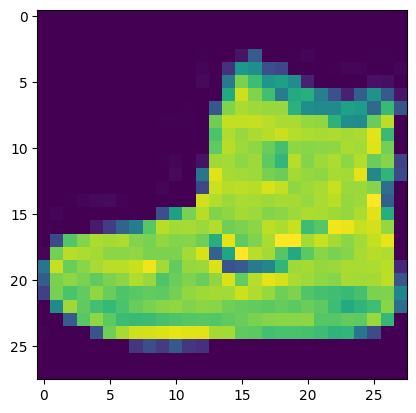

In [3]:
plt.imshow(X_train[0]);

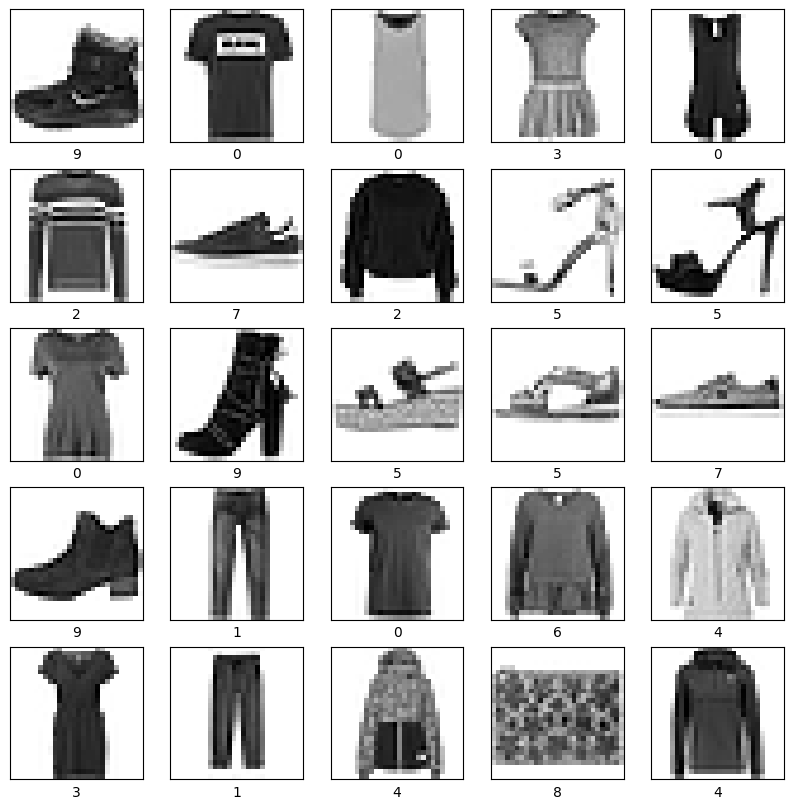

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()


In [5]:
X_train = X_train/255.0
X_test = X_test/255.0

In [6]:
haut = []
larg = []

In [7]:
for image in X_train:
    d1, d2 = image.shape;
    haut.append(d1);
    larg.append(d2);

In [8]:
np.mean(d1)

np.float64(28.0)

In [9]:
np.mean(d2)

np.float64(28.0)

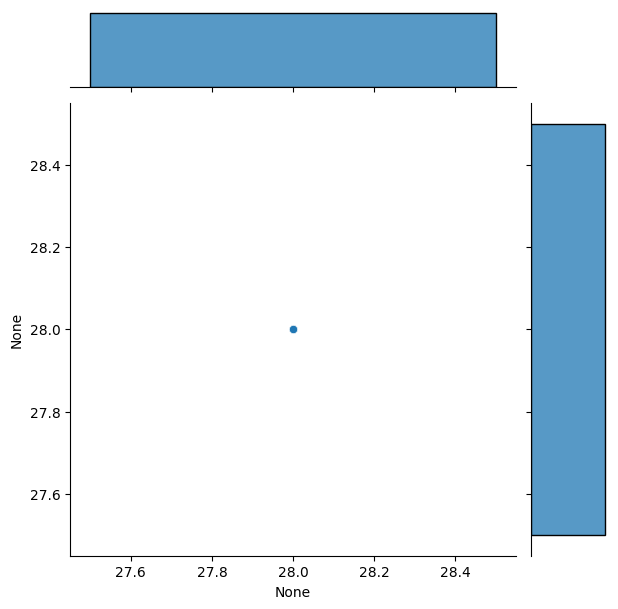

In [10]:
sns.jointplot(x=haut, y=larg);

In [11]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

In [13]:
model = Sequential()

In [14]:
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
stop = EarlyStopping(monitor='val_loss', patience=3)

In [17]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, callbacks=[stop])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.6432 - loss: 0.9605 - val_accuracy: 0.8018 - val_loss: 0.5342
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8076 - loss: 0.5321 - val_accuracy: 0.8509 - val_loss: 0.4122
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8407 - loss: 0.4402 - val_accuracy: 0.8592 - val_loss: 0.3759
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8576 - loss: 0.3918 - val_accuracy: 0.8616 - val_loss: 0.3595
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8635 - loss: 0.3658 - val_accuracy: 0.8712 - val_loss: 0.3487
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8740 - loss: 0.3415 - val_accuracy: 0.8764 - val_loss: 0.3268
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8799 - loss: 0.3262 - val_accuracy: 0.8807 - val_loss: 0.3211
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8864 - loss: 0.3072 

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,424 (1.26 MB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 220,950 (863.09 KB)

In [19]:
X_test[5].shape

(28, 28, 1)

In [20]:
prediction = np.argmax(model.predict(X_test[9].reshape(-1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


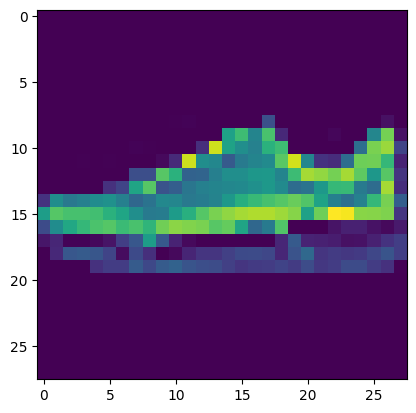

In [22]:
plt.imshow(X_test[9]);

In [23]:
prediction

np.int64(7)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8993 - loss: 0.2831


[0.28026053309440613, 0.8988999724388123]

In [26]:
model.evaluate(X_train, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9449 - loss: 0.1582


[0.1625937521457672, 0.942550003528595]

In [27]:
pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
confusion_matrix(y_test, pred.argmax(axis=1))

array([[830,   1,  26,  25,   2,   1, 107,   0,   8,   0],
       [  1, 972,   1,  19,   2,   0,   3,   0,   2,   0],
       [ 14,   0, 849,   9,  65,   0,  62,   0,   1,   0],
       [ 15,   2,  21, 897,  25,   0,  38,   0,   0,   2],
       [  1,   1,  39,  24, 855,   0,  80,   0,   0,   0],
       [  0,   0,   0,   1,   0, 980,   0,  12,   0,   7],
       [ 98,   0,  71,  24,  87,   0, 705,   0,  15,   0],
       [  0,   0,   0,   0,   0,  12,   0, 964,   0,  24],
       [  3,   0,   0,   2,   3,   2,   5,   4, 980,   1],
       [  0,   0,   0,   0,   0,   9,   0,  33,   1, 957]])

In [34]:
print(classification_report(y_test, pred.argmax(axis=1), target_names=target))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.83      0.85      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.84      0.85      0.85      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.82      0.85      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.70      0.70      0.70      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

